# Partie 1: Compréhension du métier (Business Understanding)


### 1.1 Description du métier
Le dataset représente un système de location de vélos à Seoul, où les utilisateurs peuvent louer et rendre des vélos à différents points. Des facteurs environnementaux et contextuels comme la saison, la météo, et les jours fériés influencent le comportement de location.

### 1.2 Problématique
Prédire le nombre de vélos loués en fonction des conditions environnementales et calendaires.

### 1.3 Objectifs métier et objectifs de science des données

| **Business Objective (BO)** | **Data Science Objective (DSO)** |
|-----------------------------|----------------------------------|
| **BO1**: Optimiser la disponibilité des vélos en fonction des conditions environnementales et de la demande saisonnière. | **DSO1**: Développer un modèle prédictif pour estimer le nombre de vélos loués en fonction des données environnementales et saisonnières, afin d'anticiper les périodes de forte et faible demande. |
| **BO2**: Analyser l'influence des conditions climatiques sur la visibilité des voies pour la sécurité des cyclistes. | **DSO2**: Identifier les facteurs environnementaux qui influencent fortement la visibilité afin de prendre des mesures de sécurité accrues lors de conditions défavorables. |
| **BO3**: Réduire les Périodes de Faible Utilisation par des Initiatives Promotionnelles | **DSO3**: Identifier les périodes et conditions de faible demande pour lancer des campagnes de promotion. |


# Partie 2: Compréhension des données (Data Understanding)


## 2.1 Importer les données


In [28]:
import pandas as pd
data = pd.read_csv('../Data/SeoulBikeData.csv', encoding='ISO-8859-1')


## 2.2 Description des Variables du Dataset SeoulBike


| Colonne                    | Description                                                                                      |
|----------------------------|--------------------------------------------------------------------------------------------------|
| **Date**                   | La date de l'observation.                                                                        |
| **Rented Bike Count**      | Le nombre de vélos loués pendant la période d'observation.                                       |
| **Hour**                   | L'heure de la journée au moment de l'observation.                                                |
| **Temperature(°C)**        | La température en degrés Celsius au moment de l'observation.                                     |
| **Humidity(%)**            | Le pourcentage d'humidité au moment de l'observation.                                            |
| **Wind speed (m/s)**       | La vitesse du vent en mètres par seconde au moment de l'observation.                            |
| **Visibility (10m)**       | La visibilité en mètres au moment de l'observation (par tranche de 10 mètres).                  |
| **Dew point temperature(°C)** | La température du point de rosée en degrés Celsius au moment de l'observation.              |
| **Solar Radiation (MJ/m2)** | La quantité de rayonnement solaire en mégajoules par mètre carré au moment de l'observation.    |
| **Rainfall(mm)**           | La quantité de précipitations en millimètres pendant la période d'observation.                  |
| **Snowfall(cm)**           | La quantité de neige en centimètres pendant la période d'observation.                           |
| **Seasons**                | La saison de l'année au moment de l'observation.                                                |
| **Holiday**                | Indique si l'observation a eu lieu un jour férié ou non.                                        |
| **Functioning Day**        | Indique si le système de partage de vélos fonctionnait normalement ou non pendant la période d'observation. |


## 2.3 Dimensions des données


In [29]:

print("Dimensions des données: (Nbr lignes, Nbr colonnes)", data.shape)


Dimensions des données: (Nbr lignes, Nbr colonnes) (8760, 14)


## 2.4 Afficher les premières lignes


In [30]:
data.head()


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 2.5 Afficher les dernières lignes

In [31]:
data.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


## 2.6 Statistiques descriptives des colonnes

In [32]:
data.describe()


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## 2.7 Information sur les types de données

In [33]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

## 2.8 Vérification des doublons

In [34]:
doublons = data.duplicated().sum()
print(f"Nombre de doublons : {doublons}")

Nombre de doublons : 0


## 2.9 Vérification des valeurs manquantes


In [35]:
manquants = data.isnull().sum()
print("Valeurs manquantes par colonne :\n", manquants)

Valeurs manquantes par colonne :
 Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


# Partie 3: Préparation des données



## 3.1 Nettoyage des données

### 3.1.1 Suppression des doublons


In [36]:
data = data.drop_duplicates()


### 3.1.2 Vérification s'il y a encore des doublons après suppression

In [37]:

# Vérifier les doublons
nombre_doublons = data.duplicated().sum()

# Vérifier les valeurs manquantes
valeurs_manquantes = data.isnull().sum()

# Afficher les résultats
print(f"Nombre de doublons : {nombre_doublons}")
print("Valeurs manquantes par colonne :\n", valeurs_manquantes)



Nombre de doublons : 0
Valeurs manquantes par colonne :
 Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


### 3.1.3 Imputation des valeurs manquantes


In [38]:
import pandas as pd
from sklearn.impute import SimpleImputer
data = pd.read_csv('../Data/SeoulBikeData.csv',encoding='ISO-8859-1')

# Séparer les colonnes numériques et catégorielles
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Imputation pour les colonnes numériques (moyenne)
imputer_num = SimpleImputer(strategy='mean')
data[numerical_cols] = imputer_num.fit_transform(data[numerical_cols])

# Imputation pour les colonnes catégorielles (mode)
imputer_cat = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imputer_cat.fit_transform(data[categorical_cols])

# Vérification des valeurs manquantes après imputation
valeurs_manquantes_apres = data.isnull().sum().sum()
print(f"Valeurs manquantes après imputation : {valeurs_manquantes_apres}")


Valeurs manquantes après imputation : 0


### Statistiques descriptives globales


In [39]:
# Afficher les statistiques descriptives globales
statistiques_globales = data.describe()
print(statistiques_globales)


       Rented Bike Count         Hour  Temperature(°C)  Humidity(%)  \
count        8760.000000  8760.000000      8760.000000  8760.000000   
mean          704.602055    11.500000        12.882922    58.226256   
std           644.997468     6.922582        11.944825    20.362413   
min             0.000000     0.000000       -17.800000     0.000000   
25%           191.000000     5.750000         3.500000    42.000000   
50%           504.500000    11.500000        13.700000    57.000000   
75%          1065.250000    17.250000        22.500000    74.000000   
max          3556.000000    23.000000        39.400000    98.000000   

       Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
count       8760.000000       8760.000000                8760.000000   
mean           1.724909       1436.825799                   4.073813   
std            1.036300        608.298712                  13.060369   
min            0.000000         27.000000                 -30.600000   


### Analyse des colonnes catégorielles

In [40]:
distribution_Seasons = data['Seasons'].value_counts()
distribution_Holiday = data['Holiday'].value_counts()
print(distribution_Seasons)
print(distribution_Holiday)



Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64


### Vérification de la distribution des valeurs


#### Graphique - 1 - Distribution du nombre de vélos loués

Text(0.5, 1.0, 'Distribution du nombre de vélos loués')

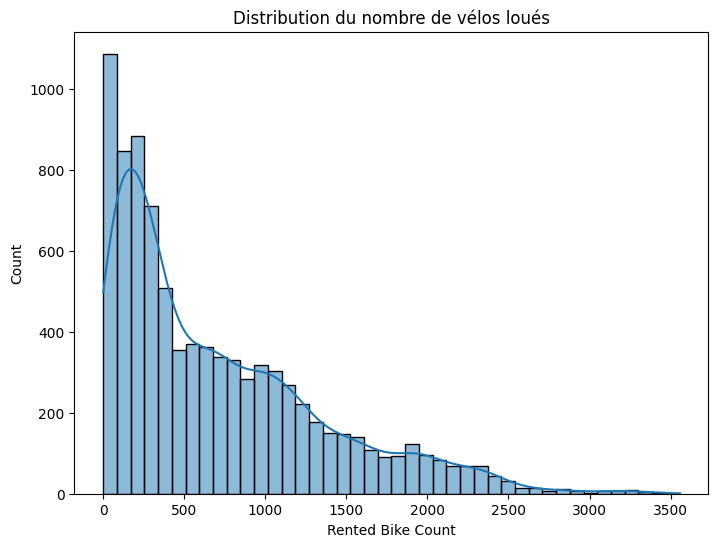

In [41]:
#!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
sns.histplot(x='Rented Bike Count',data=data, kde=True)
plt.title("Distribution du nombre de vélos loués")

#### Graphique - 2 - Distribution de la Température

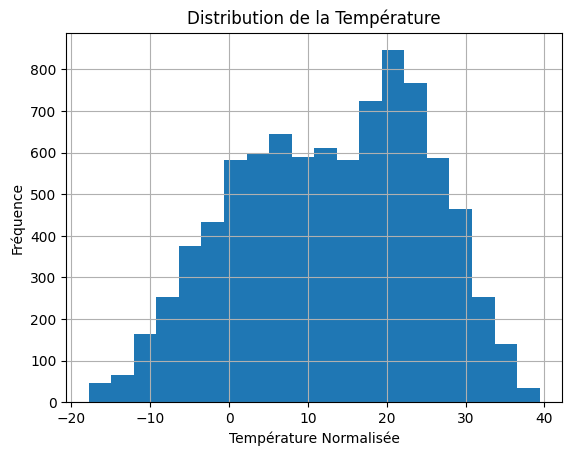

In [42]:
import matplotlib.pyplot as plt

# Afficher un histogramme des températures
data['Temperature(°C)'].hist(bins=20)
plt.title('Distribution de la Température')
plt.xlabel('Température Normalisée')
plt.ylabel('Fréquence')
plt.show()


#### Graphique - 3 - Distribution de nombre de vélos loués par saison

C:\Users\thinkpad\AppData\Local\Temp\ipykernel_21404\2139510869.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Seasons', y='Rented Bike Count', data=data, palette=palette_colors)


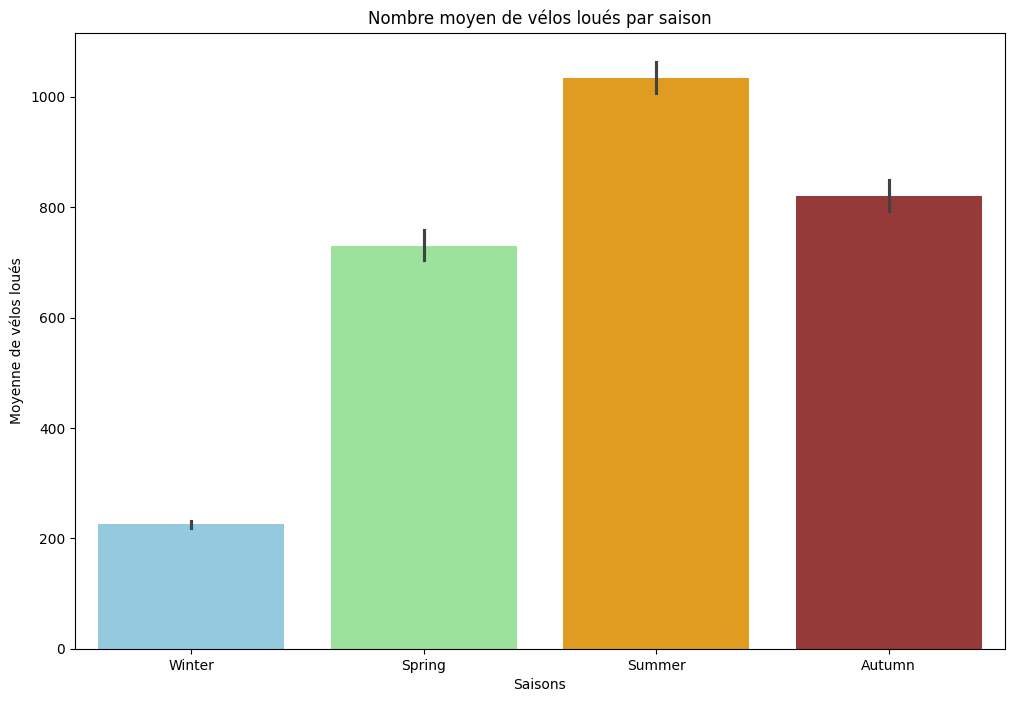

In [43]:
palette_colors = {
    'Spring': 'lightgreen',
    'Summer': 'orange',
    'Autumn': 'brown',
    'Winter': 'skyblue'
}

# Créer le graphique en barres avec des couleurs personnalisées
plt.figure(figsize=(12, 8))
sns.barplot(x='Seasons', y='Rented Bike Count', data=data, palette=palette_colors)
plt.xlabel("Saisons")
plt.ylabel("Moyenne de vélos loués")
plt.title("Nombre moyen de vélos loués par saison")
plt.show()

## 3.2 Transformation

### Encodage des Colonnes Catégorielles pour l'Analyse Prédictive
##### Description
Ce code utilise LabelEncoder de scikit-learn pour encoder plusieurs colonnes catégorielles dans un dataset de données de location de vélos. Les colonnes telles que Seasons, Holiday, et Functioning Day contiennent des valeurs non numériques qui doivent être converties en valeurs numériques avant l'analyse prédictive. Le code crée de nouvelles colonnes encodées pour chaque colonne catégorielle, puis supprime les colonnes d'origine si nécessaire. Enfin, le dataset modifié est enregistré sous le nom SeoulBikeData_encode.csv pour être prêt à l'emploi dans des modèles de machine learning nécessitant des valeurs numériques.

In [44]:
# Importer LabelEncoder de scikit-learn
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Créer un LabelEncoder
label_encoder = LabelEncoder()

# Liste des colonnes catégorielles à encoder
colonnes_categorielles = [
    'Seasons',
    'Holiday',
    'Functioning Day'
]

# Créer une copie du DataFrame pour les colonnes encodées
data_encodee = data.copy()

# Appliquer LabelEncoder à chaque colonne catégorielle et créer de nouvelles colonnes avec les valeurs encodées
for colonne in colonnes_categorielles:
    # Encoder la colonne
    data_encodee[colonne + '_encoded'] = label_encoder.fit_transform(data_encodee[colonne])

# Supprimer les colonnes d'origine si nécessaire (optionnel)
data_encodee = data_encodee.drop(columns=colonnes_categorielles)

# Enregistrer le DataFrame modifié dans un nouveau fichier CSV
data_encodee.to_csv('../Data/SeoulBikeData_encode.csv', index=False)

# Message de confirmation
print("Le fichier avec les colonnes encodées a été enregistré sous le nom 'SeoulBikeData_encode.csv'.")


Le fichier avec les colonnes encodées a été enregistré sous le nom 'SeoulBikeData_encode.csv'.


## 3.3 Normalisation

### Normalisation des variables numériques (MinMaxScaler)
##### Description
Ce code charge le dataset encode avec les nouvelles fonctionnalités , identifie les colonnes numériques, et applique une normalisation Min-Max aux colonnes spécifiées. Cette étape de prétraitement est cruciale pour garantir que les données sont sur des échelles comparables, ce qui améliore les performances et la stabilité des modèles de machine learning, en particulier ceux sensibles aux échelles de données, comme les réseaux de neurones ou les SVM. Les colonnes normalisées incluent des variables environnementales comme la température et l’humidité, ainsi que des caractéristiques calculées comme l'indice de confort. Une fois la normalisation appliquée, le dataset final est enregistré sous le nom DataFinal.csv, prêt pour l'analyse prédictive.

In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger les données avec le bon encodage
data = pd.read_csv('../Data/SeoulBikeData_Fonctionnalites_encode.csv', encoding='ISO-8859-1')

# Utilisation des noms de colonnes exacts
cols_to_normalize = [
    'Temperature(Â°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
    'Dew point temperature(Â°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
    'Snowfall (cm)', 'Rented Bike Count', 'TempÃ©rature ressentie', 'Indice_confort'
]

# Appliquer la normalisation Min-Max
scaler = MinMaxScaler()
data[cols_to_normalize] = scaler.fit_transform(data[cols_to_normalize])


# Enregistrer le DataFrame modifié dans un nouveau fichier CSV
data_encodee.to_csv('../Data/DataFinal.csv', index=False)

# Message de confirmation
print("Le fichier avec les colonnes encodées a été enregistré sous le nom 'DataFinal.csv'.")

# Afficher les premières lignes pour vérifier la normalisation
print(data.head())



Le fichier avec les colonnes encodées a été enregistré sous le nom 'DataFinal.csv'.
         Date  Rented Bike Count  Hour  Temperature(Â°C)  Humidity(%)  \
0  01/12/2017           0.071429     0          0.220280     0.377551   
1  01/12/2017           0.057368     1          0.215035     0.387755   
2  01/12/2017           0.048650     2          0.206294     0.397959   
3  01/12/2017           0.030090     3          0.202797     0.408163   
4  01/12/2017           0.021935     4          0.206294     0.367347   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(Â°C)  \
0          0.297297               1.0                    0.224913   
1          0.108108               1.0                    0.224913   
2          0.135135               1.0                    0.223183   
3          0.121622               1.0                    0.224913   
4          0.310811               1.0                    0.207612   

   Solar Radiation (MJ/m2)  Rainfall(mm)  ...  Seasons_Spring 

### Matrice de corrélation

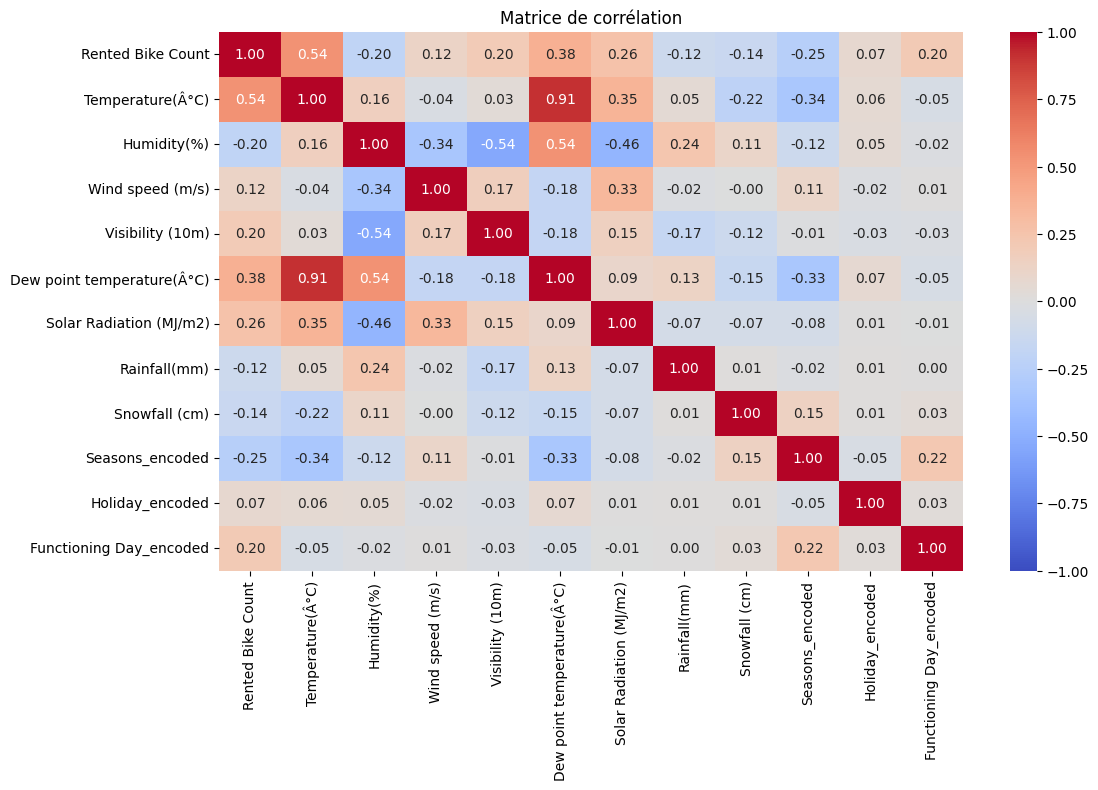

In [46]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('../Data/SeoulBikeData_encode.csv', encoding='ISO-8859-1')

corr = data.drop(['Date', 'Hour'], axis=1).corr()

# Création de la heatmap de corrélation
plt.figure(figsize=(12, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

## 3.4 Création de nouvelles fonctionnalités (Feature Engineering)

#### Extraction des caractéristiques de la date

In [47]:
import pandas as pd

# Charger les données
data = pd.read_csv('../Data/SeoulBikeData.csv', encoding='ISO-8859-1')

# 1. Température ressentie
data['Température ressentie'] = data['Temperature(°C)'] - 0.7 * data['Wind speed (m/s)']

# 2. Conditions météo extrêmes
data['Météo extrême'] = ((data['Snowfall (cm)'] > 0) | (data['Rainfall(mm)'] > 10)).astype(int)

# 3. Interaction entre les saisons et la météo extrême
data['Saison_précipitations'] = data['Seasons'] + '_' + data['Météo extrême'].astype(str)

# 4. Catégorisation de la visibilité
conditions = [
    (data['Visibility (10m)'] <= 500),
    (data['Visibility (10m)'] > 500) & (data['Visibility (10m)'] <= 2000),
    (data['Visibility (10m)'] > 2000)
]
categories = ['Faible', 'Moyenne', 'Élevée']

# Ajustement pour éviter les doublons de bornes
data['Visibilité_catégorisée'] = pd.cut(data['Visibility (10m)'], bins=[-1, 500, 2000, data['Visibility (10m)'].max() + 1], labels=categories)

# 5. Indice de confort
data['Indice_confort'] = data['Temperature(°C)'] - 0.1 * data['Humidity(%)'] - 0.7 * data['Wind speed (m/s)']

# 6. Catégorisation de l'intensité du vent
conditions_vent = [
    (data['Wind speed (m/s)'] < 1.5),
    (data['Wind speed (m/s)'] >= 1.5) & (data['Wind speed (m/s)'] < 5.0),
    (data['Wind speed (m/s)'] >= 5.0)
]
labels_vent = ['Faible', 'Modéré', 'Élevé']
data['Intensité du vent'] = pd.cut(data['Wind speed (m/s)'], bins=[-1, 1.5, 5.0, data['Wind speed (m/s)'].max()], labels=labels_vent)


data.to_csv('../Data/SeoulBikeData_Fonctionnalites.csv', index=False)

print("Les données ont été sauvegardées dans le fichier 'SeoulBikeData_Fonctionnalites.csv'.")

# Afficher les premières lignes pour vérifier les nouvelles fonctionnalités
data.head()


Les données ont été sauvegardées dans le fichier 'SeoulBikeData_Fonctionnalites.csv'.


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Température ressentie,Météo extrême,Saison_précipitations,Visibilité_catégorisée,Indice_confort,Intensité du vent
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-6.74,0,Winter_0,Moyenne,-10.44,Modéré
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-6.06,0,Winter_0,Moyenne,-9.86,Faible
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,-6.70,0,Winter_0,Moyenne,-10.60,Faible
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-6.83,0,Winter_0,Moyenne,-10.83,Faible
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-7.61,0,Winter_0,Moyenne,-11.21,Modéré


In [48]:

# Encodage binaire pour 'Holiday' et 'Functioning Day'
data['Holiday'] = data['Holiday'].map({'No Holiday': 0, 'Holiday': 1})
data['Functioning Day'] = data['Functioning Day'].map({'No': 0, 'Yes': 1})

# Encodage ordinal pour 'Visibilité_catégorisée' et 'Intensité du vent'
data['Visibilité_catégorisée'] = data['Visibilité_catégorisée'].map({'Faible': 0, 'Moyenne': 1, 'Élevée': 2})
data['Intensité du vent'] = data['Intensité du vent'].map({'Faible': 0, 'Modéré': 1, 'Élevé': 2})

# Encodage One-Hot pour 'Seasons' et 'Saison_précipitations'
data = pd.get_dummies(data, columns=['Seasons', 'Saison_précipitations'], drop_first=True)

data.to_csv('../Data/SeoulBikeData_Fonctionnalites_encode.csv', index=False)

print("Les données ont été sauvegardées dans le fichier 'SeoulBikeData_Fonctionnalites_encode.csv'.")

# Afficher les premières lignes pour vérifier l'encodage
data.head()


Les données ont été sauvegardées dans le fichier 'SeoulBikeData_Fonctionnalites_encode.csv'.


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Seasons_Spring,Seasons_Summer,Seasons_Winter,Saison_précipitations_Autumn_1,Saison_précipitations_Spring_0,Saison_précipitations_Spring_1,Saison_précipitations_Summer_0,Saison_précipitations_Summer_1,Saison_précipitations_Winter_0,Saison_précipitations_Winter_1
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,False,False,True,False,False,False,False,False,True,False


# Partie 4: Modélisation


## Modèles à utiliser :
1. **Régression linéaire** : Modèle de régression simple qui assume une relation linéaire entre les variables indépendantes et la variable cible.
2. **K-Nearest Neighbors (KNN)** : Modèle basé sur la distance entre les points, en utilisant les k voisins les plus proches pour la prédiction.
3. **Support Vector Machines (SVM)** : Modèle qui trouve l'hyperplan optimal pour séparer les données dans l'espace des caractéristiques, avec un noyau linéaire pour la régression.

## 4.1 DSO1 : Développer un modèle prédictif pour estimer le nombre de vélos loués en fonction des données environnementales et saisonnières, afin d'anticiper les périodes de forte et faible demande


## Variables principales à utiliser pour DSO1 :
- Toutes les variables des environnement,saisonnières et les nouvelles fonctionnaliés

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Charger les données
data = pd.read_csv('../Data/SeoulBikeData_Fonctionnalites_encode.csv', encoding='ISO-8859-1')

# Définir les variables d'entrée et la cible
X = data.drop(columns=['Rented Bike Count', 'Date'])  # Exclure 'Date' et 'Rented Bike Count'
y = data['Rented Bike Count']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation des données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialiser et entraîner le modèle de Régression Linéaire
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Initialiser et entraîner le modèle KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Initialiser et entraîner le modèle SVM
svm_model = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Calcul des métriques pour chaque modèle
models = {
    'Régression Linéaire': y_pred_lr,
    'KNN Regressor': y_pred_knn,
    'SVM Regressor': y_pred_svm
}

for model_name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.2f}\n")


Régression Linéaire
MSE: 194483.08
MAE: 328.56
R2: 0.53

KNN Regressor
MSE: 97129.33
MAE: 195.27
R2: 0.77

SVM Regressor
MSE: 121172.78
MAE: 212.67
R2: 0.71



| Modèle                  | MSE       | MAE      | R²     |
|-------------------------|-----------|----------|--------|
| Régression Linéaire     | 194,477.08 | 328.56   | 0.53   |
| KNN Regressor           | 97,129.33  | 195.27   | 0.77   |
| SVM Regressor           | 121,172.78 | 212.67   | 0.71   |


##### La régression linéaire est le modèle le plus performant avec le MSE le plus bas, indiquant qu'une relation linéaire simple entre les variables d'entrée et la variable cible est suffisante pour prédire le nombre de locations de vélos.


### Evaluation des modèles

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fonction pour évaluer les modèles
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - MSE: {mse}, MAE: {mae}, R²: {r2}")
    return mse, mae, r2


In [51]:
print("Évaluation des modèles pour DSO1")
# Régression Linéaire pour DSO1
evaluate_model(y_test, y_pred_lr, "Régression Linéaire DSO1")
# KNN pour DSO1
evaluate_model(y_test, y_pred_knn, "KNN DSO1")
# SVM pour DSO1
evaluate_model(y_test, y_pred_svm, "SVM DSO1")


Évaluation des modèles pour DSO1
Régression Linéaire DSO1 - MSE: 194483.07794682114, MAE: 328.56222000165945, R²: 0.5332177268262837
KNN DSO1 - MSE: 97129.33020547945, MAE: 195.26860730593606, R²: 0.7668781776605194
SVM DSO1 - MSE: 121172.78445507881, MAE: 212.6700712871005, R²: 0.7091710581102773


(np.float64(121172.78445507881),
 np.float64(212.6700712871005),
 0.7091710581102773)

### Prédiction

In [52]:
# Supposons que les modèles ont déjà été entraînés avec X_train, y_train
# Utilisation des modèles pour prédire sur X_test
# 1. Prédictions avec le modèle de Régression Linéaire
y_pred_lr = lr_model.predict(X_test)

# 2. Prédictions avec le modèle KNN
y_pred_knn = knn_model.predict(X_test)

# 3. Prédictions avec le modèle SVM
y_pred_svm = svm_model.predict(X_test)

# Afficher quelques résultats de prédiction
print("Prédictions Régression Linéaire :", y_pred_lr[:5])
print("Prédictions KNN :", y_pred_knn[:5])
print("Prédictions SVM :", y_pred_svm[:5])

# Comparer avec les valeurs réelles
print("Valeurs réelles :", y_test[:5].values)


Prédictions Régression Linéaire : [ 977.29760567 1170.29760567 1343.29760567 1320.29760567  531.29760567]
Prédictions KNN : [ 936.2  791.2  656.  1944.2  358.2]
Prédictions SVM : [ 677.18358766  681.29726029  939.8704249  1713.61471697  263.73998518]
Valeurs réelles : [1728  822  658 2716 1083]


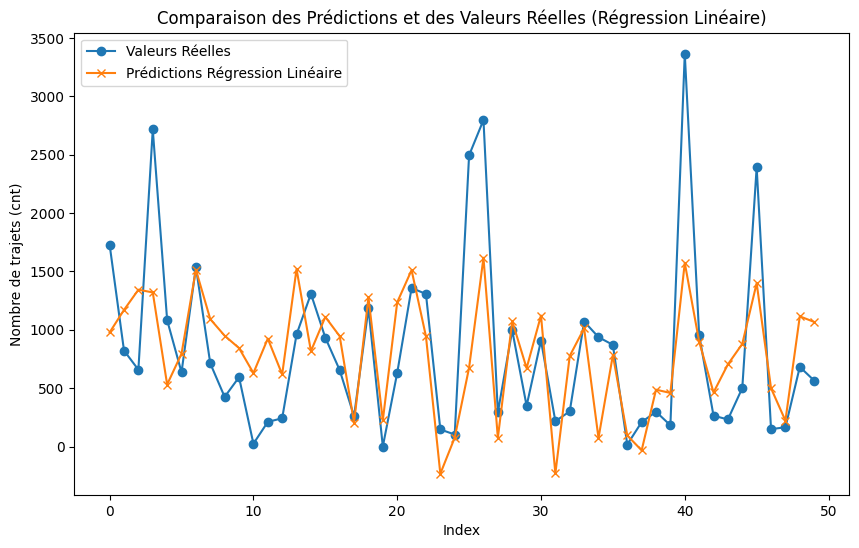

In [53]:
import matplotlib.pyplot as plt

# Comparer les prédictions avec les valeurs réelles pour Régression Linéaire
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')  # Affichage des 50 premières valeurs réelles
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Régression Linéaire)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


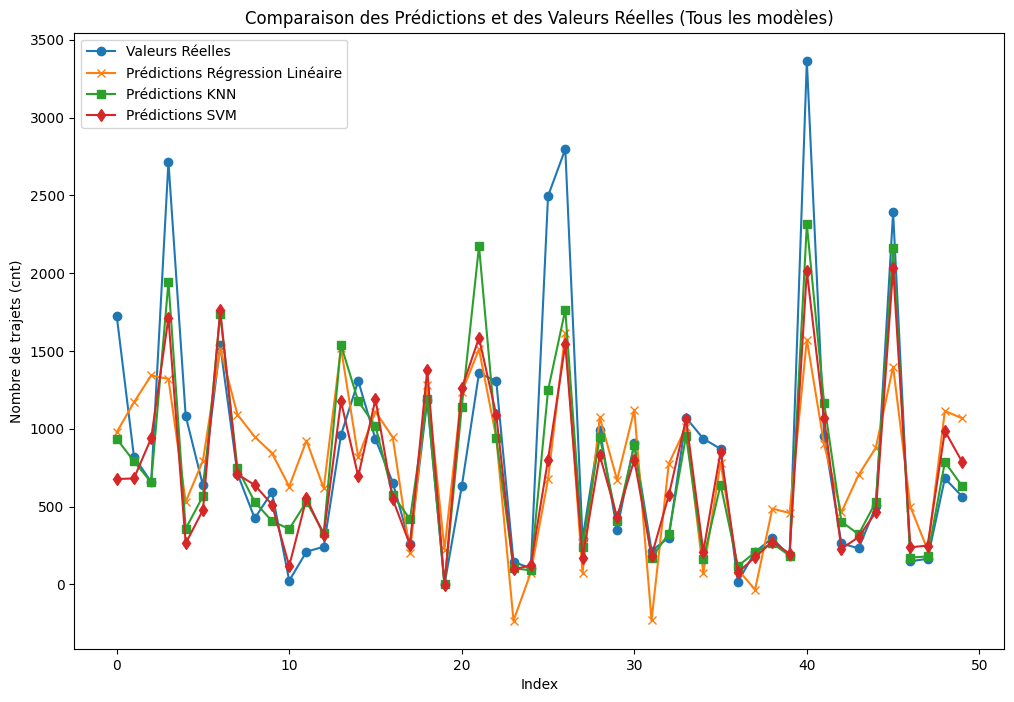

In [54]:
# Comparer les prédictions des trois modèles avec les valeurs réelles
plt.figure(figsize=(12,8))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.plot(y_pred_knn[:50], label='Prédictions KNN', marker='s')
plt.plot(y_pred_svm[:50], label='Prédictions SVM', marker='d')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Tous les modèles)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


# 4.2 DSO2 : Identifier les niveaux d'activité des utilisateurs et leurs habitudes pour ajuster la maintenance.

### Variables principales à utiliser pour DSO2 :
- Exclure 'Date' et 'Visibility (10m)'


In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Charger les données
data = pd.read_csv('../Data/SeoulBikeData_Fonctionnalites_encode.csv', encoding='ISO-8859-1')

# Définir les variables d'entrée et la cible
X = data.drop(columns=['Visibility (10m)', 'Date'])  # Exclure 'Date' et 'Visibility (10m)'
y = data['Visibility (10m)']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation des données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialiser et entraîner le modèle de Régression Linéaire
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train, y_train)
y_pred_lr2 = lin_reg2.predict(X_test)

# Initialiser et entraîner le modèle KNN
knn_model2 = KNeighborsRegressor(n_neighbors=5)
knn_model2.fit(X_train, y_train)
y_pred_knn2 = knn_model2.predict(X_test)

# Initialiser et entraîner le modèle SVM
svm_model2 = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model2.fit(X_train, y_train)
y_pred_svm2 = svm_model.predict(X_test)

# Calcul des métriques pour chaque modèle
models = {
    'Régression Linéaire': y_pred_lr2,
    'KNN Regressor': y_pred_knn2,
    'SVM Regressor': y_pred_svm2
}

print("Evaluation des modèles")
for model_name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.2f}\n")

Evaluation des modèles
Régression Linéaire
MSE: 159604.12
MAE: 323.31
R²: 0.56

KNN Regressor
MSE: 127102.82
MAE: 249.76
R²: 0.65

SVM Regressor
MSE: 1151827.04
MAE: 906.85
R²: -2.20



### Evaluation des modèles pour DSO2

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fonction pour évaluer les modèles
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - MSE: {mse}, MAE: {mae}, R²: {r2}")
    return mse, mae, r2
print("Évaluation des modèles pour DSO2")
# Régression Linéaire pour DSO1
evaluate_model(y_test, y_pred_lr2, "Régression Linéaire DSO1")
# KNN pour DSO1
evaluate_model(y_test, y_pred_knn2, "KNN DSO1")
# SVM pour DSO1
evaluate_model(y_test, y_pred_svm2, "SVM DSO1")



Évaluation des modèles pour DSO2
Régression Linéaire DSO1 - MSE: 159604.1225374516, MAE: 323.3065945367458, R²: 0.5564631826929918
KNN DSO1 - MSE: 127102.82034246575, MAE: 249.76061643835615, R²: 0.6467836825943314
SVM DSO1 - MSE: 1151827.039640415, MAE: 906.8535162533051, R²: -2.2009054097608525


(np.float64(1151827.039640415),
 np.float64(906.8535162533051),
 -2.2009054097608525)

| Modèle                  | MSE       | MAE      | R²     |
|-------------------------|-----------|----------|--------|
| Régression Linéaire     | 159604.1225374516 | 323.3065945367458   | 0.5564631826929918   |
| KNN Regressor           | 127102.82034246575  | 249.76061643835615   |  0.6467836825943314   |
| SVM Regressor           | 1115571.6215719418 | 881.7967467951199   | -2.1001522933339745   |


### Prédiction

In [57]:
# Supposons que les modèles ont déjà été entraînés avec X_train, y_train
# Utilisation des modèles pour prédire sur X_test
# 1. Prédictions avec le modèle de Régression Linéaire
y_pred_lr = lin_reg2.predict(X_test)

# 2. Prédictions avec le modèle KNN
y_pred_knn = knn_model2.predict(X_test)

# 3. Prédictions avec le modèle SVM
y_pred_svm = svm_model2.predict(X_test)

# Afficher quelques résultats de prédiction
print("Prédictions Régression Linéaire :", y_pred_lr[:5])
print("Prédictions KNN :", y_pred_knn[:5])
print("Prédictions SVM :", y_pred_svm[:5])

# Comparer avec les valeurs réelles
print("Valeurs réelles :", y_test[:5].values)


Prédictions Régression Linéaire : [1536.75086587 1469.60009654 1636.24193525 1811.17057587 1551.93099736]
Prédictions KNN : [1246.  1733.4 1868.4 1510.8 1213.4]
Prédictions SVM : [1518.21395267 1710.4944597  1906.95309032 1942.9267003  1648.58121062]
Valeurs réelles : [1999  800 1744 1637 1398]


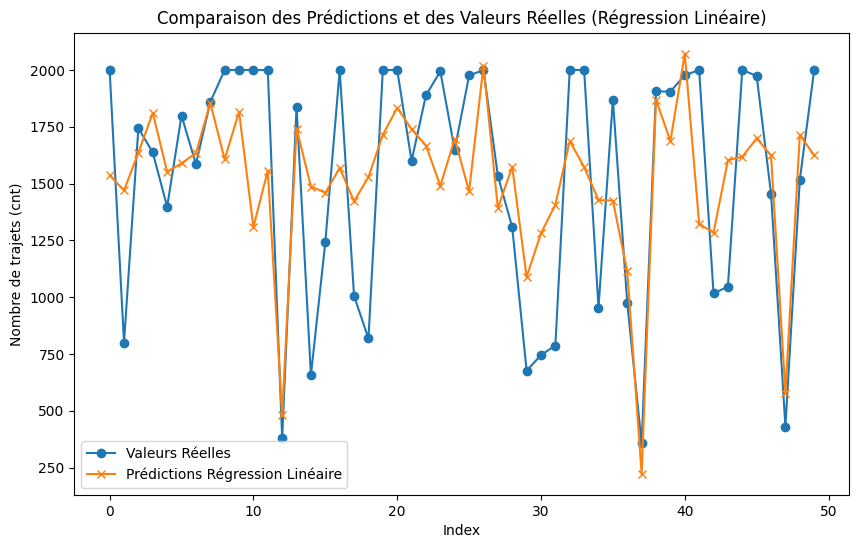

In [58]:
import matplotlib.pyplot as plt

# Comparer les prédictions avec les valeurs réelles pour Régression Linéaire
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')  # Affichage des 50 premières valeurs réelles
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Régression Linéaire)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


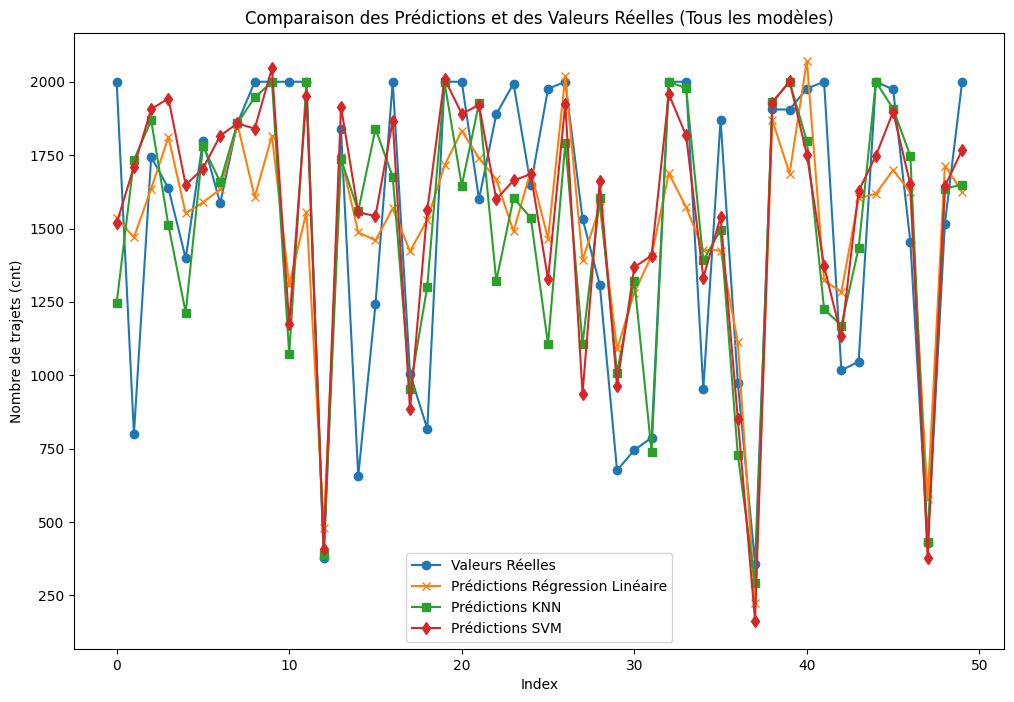

In [59]:
# Comparer les prédictions des trois modèles avec les valeurs réelles
plt.figure(figsize=(12,8))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.plot(y_pred_knn[:50], label='Prédictions KNN', marker='s')
plt.plot(y_pred_svm[:50], label='Prédictions SVM', marker='d')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Tous les modèles)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


# 4.3 DSO3 :  Identifier les périodes et conditions de faible demande pour lancer des campagnes de promotion.


### Variables principales à utiliser pour DSO3 :

- **environmental_conditions** : Conditions environnementales (température, pluie, etc.).

- **season** : Saison (encodée pour faciliter l'analyse).

- **holiday**  : Indicateur de jour férié (binaire).

- **weekday** : Jour de la semaine (encodé).

- **cnt** : Nombre de vélos loués (cible à prédire).


Ces variables couvrent les principales influences environnementales et saisonnières sur la demande de vélos et devraient fournir une base solide pour les prévisions et la détection des périodes de faible demande pour les campagnes de promotion.


In [60]:
# Importation des bibliothèques nécessaires
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


# Charger les données en ignorant les colonnes non souhaitées (Date et Hour)
data = pd.read_csv('../Data/SeoulBikeData_Fonctionnalites_encode.csv')
data = data.drop(columns=['Date', 'Hour'])


# Sélection des caractéristiques pour l'entraînement
X = data[['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
          'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)',
          'Holiday', 'Functioning Day', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter']]
y = data['Rented Bike Count']  # Nombre de vélos loués (cible)


# Diviser les données en jeu d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalisation des caractéristiques
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 1. Modèle de Régression Linéaire
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train, y_train)
y_pred_lr3 = lin_reg3.predict(X_test)


# 2. Modèle KNN
knn3 = KNeighborsRegressor(n_neighbors=10)
knn3.fit(X_train, y_train)
y_pred_knn3 = knn3.predict(X_test)


# 3. Modèle SVM (noyau linéaire)
svm3 = SVR(kernel='linear')
svm3.fit(X_train, y_train)
y_pred_svm3 = svm3.predict(X_test)


# Calcul des métriques pour chaque modèle
models = {

    'Régression Linéaire': y_pred_lr3,
    'KNN Regressor': y_pred_knn3,
    'SVM Regressor': y_pred_svm3
}

for model_name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.2f}\n")


Régression Linéaire
MSE: 218093.86
MAE: 344.02
R2: 0.48

KNN Regressor
MSE: 151457.39
MAE: 260.57
R2: 0.64

SVM Regressor
MSE: 240212.91
MAE: 337.29
R2: 0.42



### Evaluation des modèles pour DSO3

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fonction pour évaluer les modèles
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - MSE: {mse}, MAE: {mae}, R²: {r2}")
    return mse, mae, r2
print("Évaluation des modèles pour DSO2")
# Régression Linéaire pour DSO1
evaluate_model(y_test, y_pred_lr3, "Régression Linéaire DSO1")
# KNN pour DSO1
evaluate_model(y_test, y_pred_knn3, "KNN DSO1")
# SVM pour DSO1
evaluate_model(y_test, y_pred_svm3, "SVM DSO1")



Évaluation des modèles pour DSO2
Régression Linéaire DSO1 - MSE: 218093.86422772516, MAE: 344.01853445419533, R²: 0.47654906131579244
KNN DSO1 - MSE: 151457.39172945207, MAE: 260.5716324200913, R²: 0.6364844368631033
SVM DSO1 - MSE: 240212.9131774736, MAE: 337.29167087078105, R²: 0.4234607409426058


(np.float64(240212.9131774736),
 np.float64(337.29167087078105),
 0.4234607409426058)

| Modèle                  | MSE       | MAE      | R²     |
|-------------------------|-----------|----------|--------|
| Régression Linéaire     | 218093.86422772516 | 344.01853445419533   | 0.47654906131579244   |
| KNN Regressor           | 151457.39172945207  | 260.5716324200913   |  0.6364844368631033   |
| SVM Regressor           | 240212.9131774736 | 337.29167087078105   | 0.4234607409426058   |


### Prédiction

In [62]:
# Supposons que les modèles ont déjà été entraînés avec X_train, y_train
# Utilisation des modèles pour prédire sur X_test
# 1. Prédictions avec le modèle de Régression Linéaire
y_pred_lr = lin_reg3.predict(X_test)

# 2. Prédictions avec le modèle KNN
y_pred_knn = knn3.predict(X_test)

# 3. Prédictions avec le modèle SVM
y_pred_svm = svm3.predict(X_test)

# Afficher quelques résultats de prédiction
print("Prédictions Régression Linéaire :", y_pred_lr[:5])
print("Prédictions KNN :", y_pred_knn[:5])
print("Prédictions SVM :", y_pred_svm[:5])

# Comparer avec les valeurs réelles
print("Valeurs réelles :", y_test[:5].values)


Prédictions Régression Linéaire : [1041.78614445 1152.60467866 1323.6059978  1215.56238045  618.81744413]
Prédictions KNN : [1493.4  923.   784.  1621.7  380.6]
Prédictions SVM : [ 921.81025776 1140.34931042 1173.38488086  957.36656241  519.22865111]
Valeurs réelles : [1728  822  658 2716 1083]


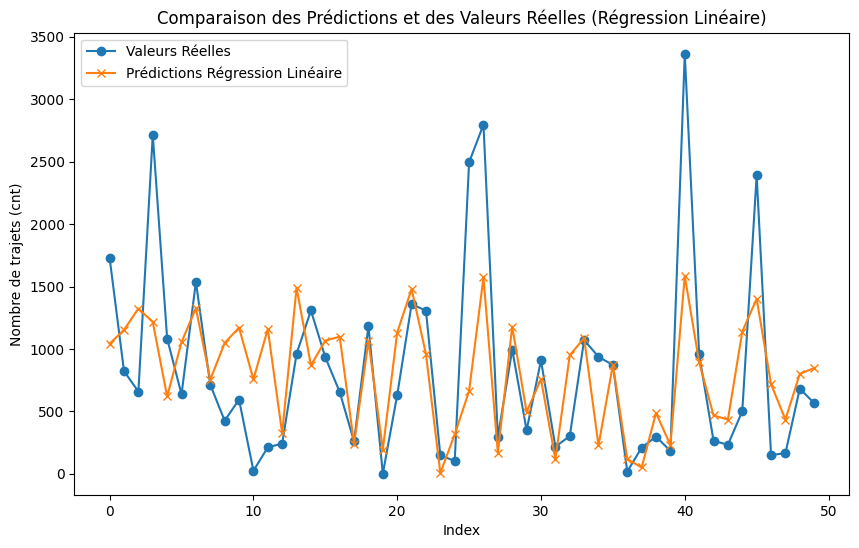

In [63]:
import matplotlib.pyplot as plt

# Comparer les prédictions avec les valeurs réelles pour Régression Linéaire
plt.figure(figsize=(10,6))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')  # Affichage des 50 premières valeurs réelles
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Régression Linéaire)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


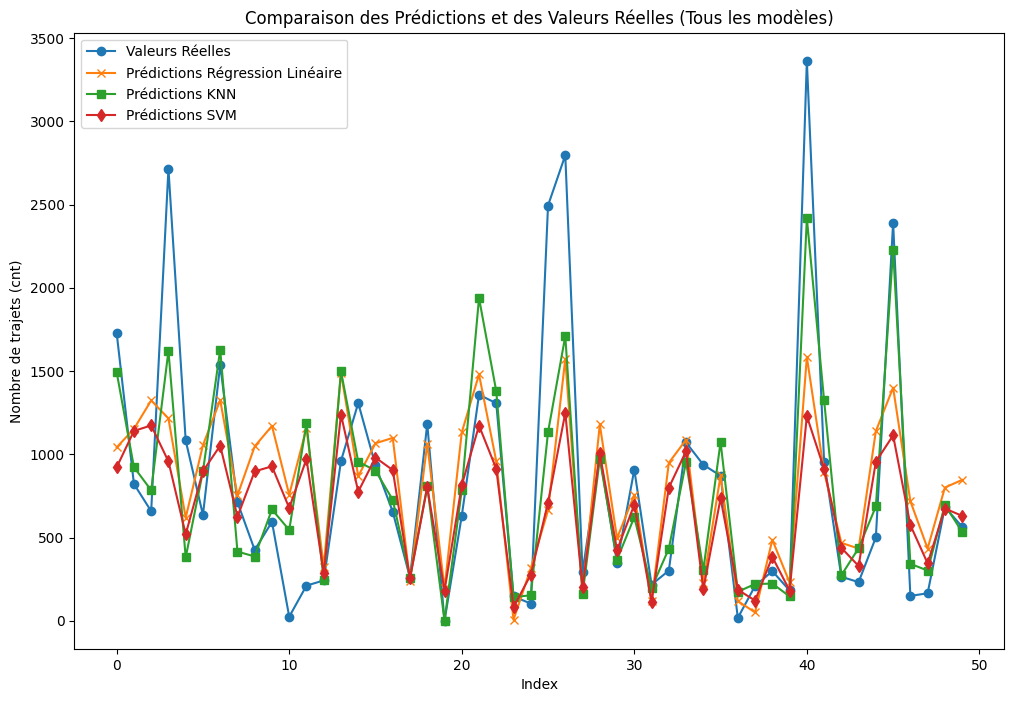

In [64]:
# Comparer les prédictions des trois modèles avec les valeurs réelles
plt.figure(figsize=(12,8))
plt.plot(y_test.values[:50], label='Valeurs Réelles', marker='o')
plt.plot(y_pred_lr[:50], label='Prédictions Régression Linéaire', marker='x')
plt.plot(y_pred_knn[:50], label='Prédictions KNN', marker='s')
plt.plot(y_pred_svm[:50], label='Prédictions SVM', marker='d')
plt.title('Comparaison des Prédictions et des Valeurs Réelles (Tous les modèles)')
plt.xlabel('Index')
plt.ylabel('Nombre de trajets (cnt)')
plt.legend()
plt.show()


# Partie 5: Déploiement


### Étapes du déploiement :
1. **Enregistrer le modèle** : Vous pouvez utiliser `joblib` ou `pickle` pour sauvegarder votre modèle.


### Enregistrement du modèle dans un fichier :



In [67]:
import joblib

# Sauvegarder les modèle
joblib.dump(svm_model, '../Model/modele_SVM_DSO1.pkl')
joblib.dump(knn_model2, '../Model/modele_KNN_DSO2.pkl')
joblib.dump(lin_reg3, '../Model/modele_Régression_Linéaire_DSO3.pkl')


['../Model/modele_Régression_Linéaire_DSO3.pkl']